# 02 – Cleaning and Resampling

Apply cleaning pipeline and show before/after statistics.

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import matplotlib.pyplot as plt
from src.config import DEV_HOUSES, TARGET_APPLIANCES
from src.io_refit import load_house
from src.mapping import standardize
from src.cleaning import clean_resample
from src.plots import plot_missing_heatmap

In [2]:
house_id = DEV_HOUSES[0]
raw = load_house(house_id, raw_dir='../data/raw')
std = standardize(raw, house_id, appliances=TARGET_APPLIANCES)
clean, stats = clean_resample(std, report=True)
print('Cleaning stats:')
for k, v in stats.items():
    print(f'  {k}: {v}')

Ambiguous local timestamps for House 2; falling back to Unix epoch column.


Cleaning stats:
  neg_replaced: {'mains': 0, 'kettle': 0, 'microwave': 0, 'fridge': 0, 'washing_machine': 0}
  outliers_capped: {'mains': 17, 'kettle': 0, 'microwave': 2, 'fridge': 502, 'washing_machine': 0}
  rows_before: 5733526
  rows_after: 889078
  missing_before_interp: {'mains': 222604, 'kettle': 222394, 'microwave': 218914, 'fridge': 218914, 'washing_machine': 223262}
  missing_after_interp: {'mains': 217286, 'kettle': 216048, 'microwave': 216031, 'fridge': 216031, 'washing_machine': 218603}
  interpolated: {'mains': 5318, 'kettle': 6346, 'microwave': 2883, 'fridge': 2883, 'washing_machine': 4659}


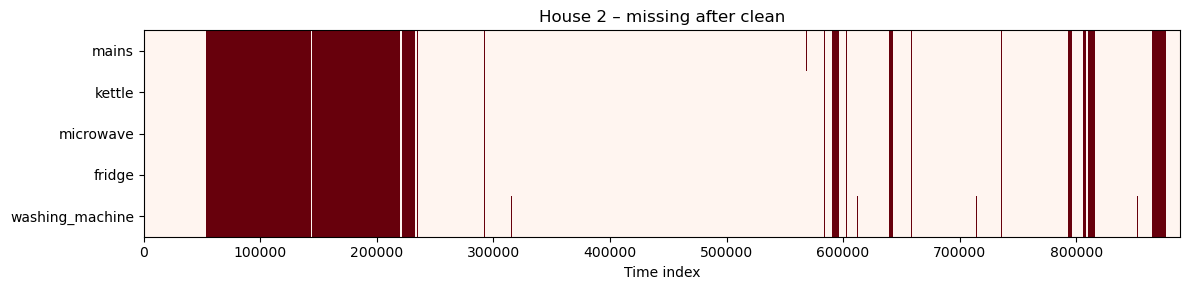

In [3]:
fig = plot_missing_heatmap(clean, title=f'House {house_id} – missing after clean')
plt.show()

In [4]:
clean.describe()

,mains,kettle,microwave,fridge,washing_machine
count,671792.000000,673030.000000,673047.000000,673047.000000,670475.000000
mean,397.824864,0.057053,3.228063,35.704893,3.733758
std,677.829018,0.990970,48.576266,42.998722,20.997831
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,107.250000,0.000000,0.000000,1.000000,0.000000
50%,167.555556,0.000000,0.000000,1.000000,0.000000
75%,326.714286,0.000000,0.000000,84.000000,0.000000
max,8517.000000,36.000000,1216.285714,172.300000,453.000000
